#**Practice**


In [ ]:
import urllib.request
import zipfile
import os

print("Downloading MovieLens 100K dataset...")
urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-100k.zip", "ml-100k.zip")

print("Extracting...")
with zipfile.ZipFile("ml-100k.zip", 'r') as zip_ref:
    zip_ref.extractall(".")
print("Done! You should see a folder called 'ml-100k'")

Extracting...
Done! You should see a folder called 'ml-100k'


# **TOOLS FOR MODEL TRAINING**


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:

column_names = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=column_names)

# Let's see what we loaded
print(ratings.head())

# Check the shape (rows, columns)
print(f"Total ratings: {len(ratings)}")
print(f"Unique users: {ratings['user_id'].nunique()}")
print(f"Unique movies: {ratings['movie_id'].nunique()}")
print(f"Ratings go from {ratings['rating'].min()} to {ratings['rating'].max()} stars")

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
Total ratings: 100000
Unique users: 943
Unique movies: 1682
Ratings go from 1 to 5 stars


In [ ]:
all_user_ids = ratings['user_id'].unique()
user_phonebook = {}
for i,user_id in enumerate(all_user_ids):
  user_phonebook[user_id]= i
print(len(user_phonebook))
print(user_phonebook[1])


all_movie_ids = ratings['movie_id'].unique()
movie_phonebook = {}
for j,movie_id in enumerate(all_movie_ids): # Corrected: used all_movie_ids here
  movie_phonebook[movie_id]= j
print(len(movie_phonebook))
print(movie_phonebook[1])

943
118
1682
24


In [ ]:
ratings['user_index']=ratings['user_id'].map(user_phonebook)
ratings['movie_index']=ratings['movie_id'].map(movie_phonebook)
comparizon = ratings[['user_id','user_index','movie_id','movie_index','rating']].head()
print(comparizon)

   user_id  user_index  movie_id  movie_index  rating
0      196           0       242            0       3
1      186           1       302            1       3
2       22           2       377            2       1
3      244           3        51            3       2
4      166           4       346            4       1


Now Spliting data beefore we were just orgnizing our data

In [ ]:
X = ratings[['user_index','movie_index']].values
Y = ratings['rating'].values
print(X.shape)
print(Y.shape)
X_train,X_test,Y_train,Y_test = train_test_split(
  X,Y ,test_size=0.2,random_state=42
)
print(len(X_test))
print(len(X_train))

(100000, 2)
(100000,)
20000
80000


**Now building the basic nural network**

In [ ]:
n_users = len(user_phonebook)
n_movies = len(movie_phonebook)
embedding_size = 50
# input layer of user
user_input = keras.layers.Input(shape=(1,), name='user_input')
#embadding layer
user_embedding =keras.layers.Embedding(n_users,embedding_size,name="user_embedding")(user_input)
#flatten layer
user_vector =keras.layers.Flatten(name='user_flatten')(user_embedding)

#input layer of movies
movie_input = keras.layers.Input(shape=(1,),name='movie_input')
#embadding layer
movie_embedding =keras.layers.Embedding(n_movies,embedding_size,name='movie_embedding')(movie_input)
#flatten layer
movie_vector =keras.layers.Flatten(name='movie_flatten')(movie_embedding)

#combining movies and user
concat= keras.layers.Concatenate(name ='concat')([user_vector,movie_vector])

#making hidden layers
hidden1 =keras.layers.Dense(128,activation='relu',name='hidden1')(concat)
#applying dropout on layer 1 so that we can avoid overfitting
dropout1=keras.layers.Dropout(0.5,name='dropout1')(hidden1)
#making 2hidden layer
hidden2 =keras.layers.Dense(128,activation='relu',name='hidden2')(dropout1)
#applying dropout on layer 2 so that we can avoid overfitting
dropout2=keras.layers.Dropout(0.5,name='dropout2')(hidden2)
hidden3 =keras.layers.Dense(128,activation='relu',name='hidden3')(dropout2)
#applying dropout on layer 2 so that we can avoid overfitting
dropout3=keras.layers.Dropout(0.5,name='dropout3')(hidden3)


#output layer
output =keras.layers.Dense(1,name='output')(dropout2)

#making model
model =keras.Model(
    inputs=[user_input,movie_input],
    outputs=output
)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss ='mse',
    metrics = ['mae']
)

In [ ]:
from re import VERBOSE
train_users = X_train[:,0]
train_movies = X_train[:,1]

history = model.fit(
    x= [train_users,train_movies],
    y=Y_train,
    batch_size = 64,
    epochs =10,
    validation_split=0.2,
    verbose=1

)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 1.5759 - mae: 0.9789 - val_loss: 0.9265 - val_mae: 0.7701
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.1005 - mae: 0.8391 - val_loss: 0.9101 - val_mae: 0.7610
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.0404 - mae: 0.8139 - val_loss: 0.8961 - val_mae: 0.7485
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.0087 - mae: 0.8010 - val_loss: 0.8919 - val_mae: 0.7510
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9672 - mae: 0.7841 - val_loss: 0.8875 - val_mae: 0.7550
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.9283 - mae: 0.7657 - val_loss: 0.8890 - val_mae: 0.7467
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.8940 - mae: 0.7514 - val_loss: 0.8809 - val_mae: 0.7506
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.8590 - mae: 0.7374 - val_loss: 0.8806 - val_mae: 0.7503
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━

In [ ]:
test_user =X_test[:,0]
test_movies=X_test[:,1]
predictins=model.predict([test_user,test_movies],verbose=0).flatten()

rmse = np.sqrt(np.mean((Y_test - predictins) ** 2))
mae = np.mean(np.abs(Y_test - predictins))
print(rmse)
print(mae)

0.9413061633445168
0.7453247270405292


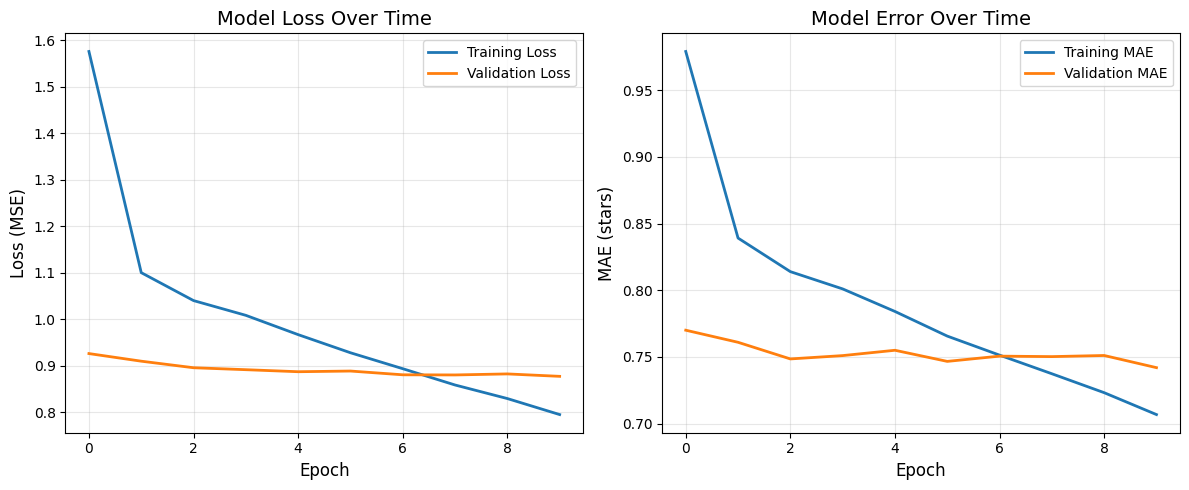

📈 The graph shows:
  • Loss decreasing = model is learning
  • Gap between lines = overfitting (memorizing vs generalizing)
  • Flat line at end = model has learned all it can


In [ ]:
# Draw a graph to see how the model improved over time

plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Time', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Model Error Over Time', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE (stars)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 The graph shows:")
print("  • Loss decreasing = model is learning")
print("  • Gap between lines = overfitting (memorizing vs generalizing)")
print("  • Flat line at end = model has learned all it can")

# **Model with NCF**





In [ ]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("🎬 Starting...")

# 2. LOAD DATA
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user','movie','rating','time'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', usecols=[0,1], names=['id','title'])

print(f"Loaded {len(ratings)} ratings")

# 3. PREPROCESSING
users = ratings['user'].unique()
movies_list = ratings['movie'].unique()

# Create mappings
user_dict = {u:i for i,u in enumerate(users)}
movie_dict = {m:i for i,m in enumerate(movies_list)}
movie_titles = dict(zip(movies['id'], movies['title']))

# Add indexes
ratings['user_idx'] = ratings['user'].map(user_dict)
ratings['movie_idx'] = ratings['movie'].map(movie_dict)

# Normalize ratings (0-1 range)
ratings['rating_norm'] = (ratings['rating'] - 1) / 4

# 4. PREPARE DATA
X = ratings[['user_idx','movie_idx']].values
y = ratings['rating_norm'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Users: {len(users)}, Movies: {len(movies_list)}")

# 5. BUILD MODEL
user_input = layers.Input(shape=(1,))
movie_input = layers.Input(shape=(1,))

user_emb = layers.Embedding(len(users), 32)(user_input)
movie_emb = layers.Embedding(len(movies_list), 32)(movie_input)

user_vec = layers.Flatten()(user_emb)
movie_vec = layers.Flatten()(movie_emb)

concat = layers.Concatenate()([user_vec, movie_vec])
dense = layers.Dense(64, activation='relu')(concat)
dropout = layers.Dropout(0.3)(dense)
output = layers.Dense(1, activation='sigmoid')(dropout)

model = tf.keras.Model([user_input, movie_input], output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 6. TRAIN
history = model.fit(
    [X_train[:,0], X_train[:,1]],
    y_train,
    batch_size=256,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# 7. TEST
y_pred_norm = model.predict([X_test[:,0], X_test[:,1]], verbose=0).flatten()
y_pred = y_pred_norm * 4 + 1
y_test_orig = y_test * 4 + 1

rmse = np.sqrt(np.mean((y_test_orig - y_pred)**2))
mae = np.mean(np.abs(y_test_orig - y_pred))
print(f"\n📊 Results - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# 8. ✅ FIXED RECOMMEND FUNCTION (with proper numpy arrays)
def recommend(user_id, n=5):
    """Get movie recommendations for a user"""

    # Get user index
    if user_id not in user_dict:
        print(f"User {user_id} not found")
        return

    user_idx = user_dict[user_id]

    # Movies user already rated
    seen_movies = set(ratings[ratings['user'] == user_id]['movie_idx'].values)

    # All movies
    all_movies = list(range(len(movies_list)))

    # Movies user hasn't seen
    unseen_movies = [m for m in all_movies if m not in seen_movies]

    if len(unseen_movies) == 0:
        print("User has seen all movies!")
        return

    # ✅ FIX: Convert to numpy arrays CORRECTLY
    user_array = np.array([user_idx] * len(unseen_movies), dtype=np.int32)
    movie_array = np.array(unseen_movies, dtype=np.int32)

    # Predict
    predictions_norm = model.predict([user_array, movie_array], verbose=0).flatten()
    predictions = predictions_norm * 4 + 1  # Convert back to 1-5 scale

    # Get top n
    top_indices = np.argsort(predictions)[-n:][::-1]

    # Show results
    print(f"\n🔥 Top {n} recommendations for User {user_id}:")
    print("-" * 60)

    for i, idx in enumerate(top_indices, 1):
        movie_idx = unseen_movies[idx]
        # Find movie ID from movie_idx
        movie_id = list(movie_dict.keys())[list(movie_dict.values()).index(movie_idx)]
        title = movie_titles.get(movie_id, f"Movie {movie_id}")
        if len(title) > 40:
            title = title[:37] + "..."
        rating = predictions[idx]
        print(f"{i:2d}. ⭐ {rating:.2f} - {title}")

# Test it
recommend(2)

print("\n✅ Done!")

🎬 Starting...
Loaded 100000 ratings
Users: 943, Movies: 1682
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0762 - mae: 0.2245 - val_loss: 0.0567 - val_mae: 0.1888
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0544 - mae: 0.1844 - val_loss: 0.0550 - val_mae: 0.1854
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0522 - mae: 0.1802 - val_loss: 0.0545 - val_mae: 0.1844
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0515 - mae: 0.1791 - val_loss: 0.0543 - val_mae: 0.1844
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0512 - mae: 0.1788 - val_loss: 0.0542 - val_mae: 0.1838
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0503 - mae: 0.1771 - val_loss: 0.0543 - val_mae: 0.1839
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0495 - mae: 0.1755 - val_loss: 0.0543 - val_mae: 0.1841
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0489 - mae: 0.1744 - val_loss: 0.0543 - val_mae: 0.

# **Custom build Model**

🎬 MOVIE RECOMMENDATION SYSTEM - TRAINING STARTED!
📥 Downloading MovieLens 100K dataset...
✅ Dataset downloaded!
📊 Users: 943, Movies: 1682, Ratings: 100000
📚 Training: 80000, 📝 Testing: 20000

🧠 Model built! Training...
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 3.3774 - mae: 1.3730 - val_loss: 0.9243 - val_mae: 0.7647
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9652 - mae: 0.7822 - val_loss: 0.9038 - val_mae: 0.7580
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9117 - mae: 0.7566 - val_loss: 0.8837 - val_mae: 0.7428
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.8648 - mae: 0.7364 - val_loss: 0.8741 - val_mae: 0.7390
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8348 - mae: 0.7228 - val_loss: 0.8708 - val_mae: 0.7329
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.8070 - mae: 0.7075 - val_loss: 0.8695 - val_mae: 0.7340
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss

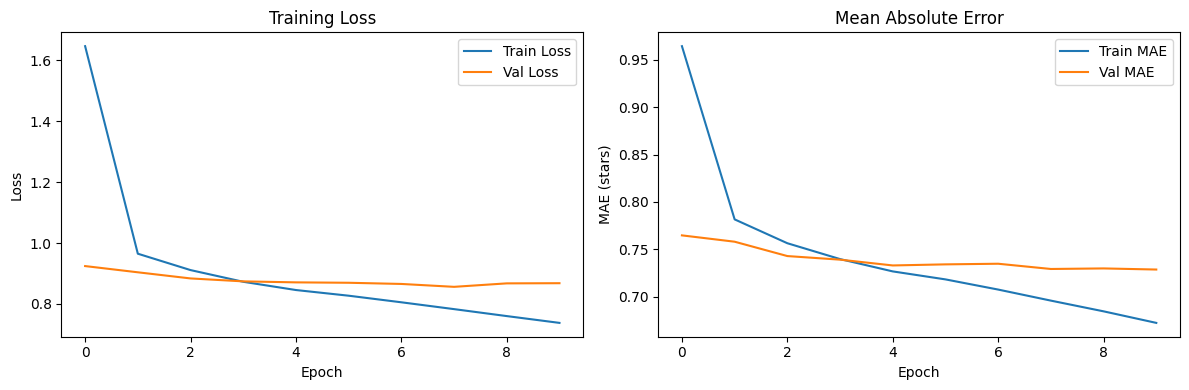


🔥 Top 5 for User 1:
1. ⭐ 5.21 - Faust (1994)
2. ⭐ 5.19 - Bitter Sugar (Azucar Amargo) (1996)
3. ⭐ 5.05 - Pather Panchali (1955)
4. ⭐ 4.96 - Spanish Prisoner, The (1997)
5. ⭐ 4.94 - Delta of Venus (1994)


In [ ]:
# 🎬 YOUR FIRST NEURAL NETWORK - COMPLETE WORKING VERSION
# Copy this entire cell and run it!

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os

print("🎬 MOVIE RECOMMENDATION SYSTEM - TRAINING STARTED!")
print("="*60)

# 1. DOWNLOAD DATASET
if not os.path.exists('ml-100k'):
    print("📥 Downloading MovieLens 100K dataset...")
    urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-100k.zip", "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✅ Dataset downloaded!")

# 2. LOAD DATA
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', usecols=[0,1], names=['movie_id','title'])

# 3. CREATE MAPPINGS
users = ratings['user_id'].unique()
movies_list = ratings['movie_id'].unique()
user_to_idx = {u:i for i,u in enumerate(users)}
movie_to_idx = {m:i for i,m in enumerate(movies_list)}
idx_to_movie = {i:m for m,i in movie_to_idx.items()}
movie_titles = dict(zip(movies['movie_id'], movies['title']))

# 4. PREPARE DATA
ratings['user_idx'] = ratings['user_id'].map(user_to_idx)
ratings['movie_idx'] = ratings['movie_id'].map(movie_to_idx)
X = ratings[['user_idx','movie_idx']].values
y = ratings['rating'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Users: {len(users)}, Movies: {len(movies_list)}, Ratings: {len(ratings)}")
print(f"📚 Training: {len(X_train)}, 📝 Testing: {len(X_test)}")

# 5. BUILD MODEL
n_users = len(users)
n_movies = len(movies_list)

user_input = layers.Input(shape=(1,))
user_emb = layers.Embedding(n_users, 50)(user_input)
user_vec = layers.Flatten()(user_emb)

movie_input = layers.Input(shape=(1,))
movie_emb = layers.Embedding(n_movies, 50)(movie_input)
movie_vec = layers.Flatten()(movie_emb)

concat = layers.Concatenate()([user_vec, movie_vec])
dense1 = layers.Dense(64, activation='relu')(concat)
dropout1 = layers.Dropout(0.3)(dense1)
dense2 = layers.Dense(32, activation='relu')(dropout1)
output = layers.Dense(1)(dense2)

model = keras.Model(inputs=[user_input, movie_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\n🧠 Model built! Training...")

# 6. TRAIN
history = model.fit(
    [X_train[:,0], X_train[:,1]], y_train,
    batch_size=64, epochs=10, validation_split=0.2, verbose=1
)

# 7. EVALUATE
y_pred = model.predict([X_test[:,0], X_test[:,1]], verbose=0).flatten()
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mae = np.mean(np.abs(y_test - y_pred))
print(f"\n📊 Test RMSE: {rmse:.4f}, Test MAE: {mae:.4f}")

# 8. PLOT RESULTS
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE (stars)')
plt.legend()
plt.tight_layout()
plt.show()

# 9. RECOMMEND MOVIES
def recommend(user_id, n=5):
    user_idx = user_to_idx[user_id]
    rated = set(ratings[ratings['user_id']==user_id]['movie_idx'])
    unseen = list(set(range(n_movies)) - rated)
    users_array = np.full(len(unseen), user_idx)
    preds = model.predict([users_array, np.array(unseen)], verbose=0).flatten()
    top_idx = np.argsort(preds)[-n:][::-1]

    print(f"\n🔥 Top {n} for User {user_id}:")
    for i, pos in enumerate(top_idx, 1):
        movie_id = idx_to_movie[unseen[pos]]
        title = movie_titles.get(movie_id, "Unknown")
        print(f"{i}. ⭐ {preds[pos]:.2f} - {title}")

recommend(1, 5)

In [ ]:
def recommend(user_id, n=5):
    user_idx = user_to_idx[user_id]
    rated = set(ratings[ratings['user_id']==user_id]['movie_idx'])
    unseen = list(set(range(n_movies)) - rated)
    users_array = np.full(len(unseen), user_idx)
    preds = model.predict([users_array, np.array(unseen)], verbose=0).flatten()
    top_idx = np.argsort(preds)[-n:][::-1]

    print(f"\n🔥 Top {n} for User {user_id}:")
    for i, pos in enumerate(top_idx, 1):
        movie_id = idx_to_movie[unseen[pos]]
        title = movie_titles.get(movie_id, "Unknown")
        print(f"{i}. ⭐ {preds[pos]:.2f} - {title}")

recommend(3, 10)


🔥 Top 10 for User 3:
1. ⭐ 4.15 - Bitter Sugar (Azucar Amargo) (1996)
2. ⭐ 3.95 - Faust (1994)
3. ⭐ 3.87 - Pather Panchali (1955)
4. ⭐ 3.79 - Some Mother's Son (1996)
5. ⭐ 3.76 - Delta of Venus (1994)
6. ⭐ 3.74 - To Kill a Mockingbird (1962)
7. ⭐ 3.72 - Perfect Candidate, A (1996)
8. ⭐ 3.70 - Cérémonie, La (1995)
9. ⭐ 3.70 - Usual Suspects, The (1995)
10. ⭐ 3.69 - Murder in the First (1995)
